# LoftIQ GitHub-safe pigeon racing notebook

This version is safe for GitHub because the real pigeon ring numbers are replaced with LoftIQ AKA ring numbers.

The public CSV uses `LOFTIQ-BIRD-0001` style IDs so birds can still be tracked inside this LoftIQ project without exposing the original ring numbers.

Keep `LoftIQ_PRIVATE_ring_alias_map_DO_NOT_UPLOAD.csv` private. That file is only for tracing an AKA bird back to the real ring number.


# Pigeon Racing AI — GitHub-safe race prediction notebook

This notebook loads the clean CSV file:

```text
LoftIQ.csv
```

It checks the available 2026 pigeons, trains on past race results, and ranks the available birds for the next race.

This is not a magic winner picker. Pigeon racing has too many moving parts: weather, basket stress, release timing, route behaviour, hawks, health, and dirty historical data. The notebook gives a ranked shortlist. The final basket decision still needs human judgement.

## What this notebook does

1. Loads the GitHub-safe CSV.
2. Rebuilds `ring_norm` from the current `Ring Number`.
3. Recalculates the Word match fields from the current ring number:
   - `Word Match Count`
   - `Word Source Rows`
   - `Word Matched Ring(s)`
   - `Word Color(s)`
   - `Word Pairing From Column C`
4. Trains the model from past race rows.
5. Predicts and ranks only the available active birds.
6. Saves outputs to the `outputs/` folder.

## GitHub-safe rules

- No private Google Sheet ID.
- No private Google Drive path.
- No `` naming in the CSV headers.
- Runs from a CSV in the same folder as the notebook.


In [ ]:
import importlib.util
import subprocess
import sys
import os
import re
from datetime import datetime
from math import radians, degrees, sin, cos, atan2
from pathlib import Path

PACKAGE_IMPORTS = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "sklearn",
}

for package, import_name in PACKAGE_IMPORTS.items():
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.ensemble import RandomForestRegressor, VotingRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.2f}".format)

print("Imports ready.")


Imports ready.


## Step 2 — Set notebook options

This cell sets the CSV file, available year, training seasons, and next race conditions.

The important change: this notebook runs from a local CSV, not from a private Google Sheet. That is what makes it safe for GitHub.

Change the next-race values before running a new prediction.


In [ ]:
# CSV file expected in the same folder as this notebook.
import importlib.util
import subprocess
import sys

# Install gdown if not already installed
if importlib.util.find_spec('gdown') is None:
    print('Installing gdown...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'])
import gdown

GOOGLE_DRIVE_FILE_ID = '1ywlby0UFBeGRiDpadkxnB4MM2KSotiQ_'
OUTPUT_FILENAME = 'LoftIQ.csv'

gdown.download(id=GOOGLE_DRIVE_FILE_ID, output=OUTPUT_FILENAME, quiet=False)

INPUT_CSV_PATH = os.getenv('PIGEON_AI_INPUT_CSV', OUTPUT_FILENAME)

# Year used to filter the available birds.
AVAILABLE_LIST_YEAR = 2026

# Seasons used to train from past results.
TRAINING_SEASONS = [2023, 2024, 2025, 2026]

# Output files.
WRITE_OUTPUTS = True
OUTPUT_DIR = Path('outputs')
OUTPUT_PREDICTIONS = OUTPUT_DIR / 'predictions_available_birds.csv'
OUTPUT_BEST40 = OUTPUT_DIR / 'best_40_available_birds.csv'
OUTPUT_AUDIT = OUTPUT_DIR / 'prediction_audit.csv'
OUTPUT_PAIR_PERFORMANCE = OUTPUT_DIR / 'pair_performance_available_birds.csv'

TOP_N = 40

# Loft location.
LOFT_LAT = -29.12
LOFT_LON = 26.21
LOFT_NAME = 'Your Loft'

# Known release locations.
KNOWN_LOCATIONS = {
    'Graaff-Reinet': {'lat': -32.25, 'lon': 24.53},
    'Middelburg': {'lat': -31.48, 'lon': 25.00},
    'Cradock': {'lat': -32.15, 'lon': 25.63},
    'Prince Albert': {'lat': -33.21, 'lon': 22.03},
    'Matjiesfontein': {'lat': -33.23, 'lon': 20.58},
    'Touwsrivier': {'lat': -33.30, 'lon': 20.05},
    'Aberdeen': {'lat': -32.46, 'lon': 24.05},
    'Leeu Gamka': {'lat': -32.78, 'lon': 21.96},
    'Laingsburg': {'lat': -33.18, 'lon': 20.86},
    'Willowmore': {'lat': -33.25, 'lon': 23.48},
    'Colesberg': {'lat': -30.71, 'lon': 25.08},
    'Beaufort Wes': {'lat': -32.33, 'lon': 22.65},
    'Skietkuil': {'lat': -31.70, 'lon': 23.43},
    'Springfontein': {'lat': -30.23, 'lon': 25.71},
}

# Next race values to update before prediction.
NEXT_RACE_NAME = 'Next Race'
NEXT_RACE_DATE = '2026-09-06'
NEXT_RELEASE_LOC = 'Graaff-Reinet'
NEXT_RELEASE_LAT = KNOWN_LOCATIONS[NEXT_RELEASE_LOC]['lat']
NEXT_RELEASE_LON = KNOWN_LOCATIONS[NEXT_RELEASE_LOC]['lon']
NEXT_RACE_DISTANCE = 380.0
NEXT_TEMP_C = 18.0
NEXT_WIND_KMH = 20.0
NEXT_WIND_DIR = 155.0  # Wind direction the wind comes from.

print('Config ready.')
print('Input CSV:', INPUT_CSV_PATH)
print('Prediction candidate rule: Race Cage Year(s) contains', AVAILABLE_LIST_YEAR)
print('Next race:', NEXT_RACE_NAME, NEXT_RACE_DATE, NEXT_RELEASE_LOC)


Downloading...
From: https://drive.google.com/uc?id=1ywlby0UFBeGRiDpadkxnB4MM2KSotiQ_
To: /content/LoftIQ.csv
100%|██████████| 8.02M/8.02M [00:00<00:00, 29.0MB/s]

Config ready.
Input CSV: LoftIQ.csv
Prediction candidate rule: Race Cage Year(s) contains 2026
Next race: Next Race 2026-09-06 Graaff-Reinet


## Step 3 — Helper functions

These functions keep the rest of the notebook cleaner.

The important parts are:

- `normalize_ring()` cleans ring numbers into one matching format.
- `recalculate_word_match_columns()` rebuilds the Word match columns from the current `Ring Number`.
- `write_df_to_csv()` saves notebook outputs into the `outputs/` folder.

If ring numbers are not standardised, the notebook cannot correctly match race history, family history, or available birds.


In [ ]:
def clean_col_name(value):
    return re.sub(r"[^a-z0-9]+", "_", str(value).strip().lower()).strip("_")

def dedupe_columns(df):
    return df.loc[:, ~pd.Index(df.columns).duplicated()].copy()

def write_df_to_csv(path, df):
    path.parent.mkdir(parents=True, exist_ok=True)
    out = dedupe_columns(df.copy())
    out = out.replace([np.inf, -np.inf], np.nan).fillna("")
    out.to_csv(path, index=False)
    print(f"Wrote {len(out):,} rows to: {path}")

def to_num(s):
    return pd.to_numeric(
        s.astype(str)
         .str.replace(",", "", regex=False)
         .str.replace(" ", "", regex=False)
         .str.strip(),
        errors="coerce"
    )

def normalize_ring(value):
    if value is None or pd.isna(value):
        return ""
    text = str(value).upper().strip()
    text = text.replace("_", "-").replace("/", "-").replace("\\", "-")
    text = text.replace("’", "").replace("'", "")
    text = re.sub(r"\s+", "-", text)
    text = re.sub(r"[^A-Z0-9-]", "", text)
    text = re.sub(r"-+", "-", text).strip("-")
    m = re.match(r"^(ZA)-?(20\d{2})-?([A-Z]+)-?0*(\d+)$", text)
    if m:
        return f"{m.group(1)}-{m.group(2)}-{m.group(3)}-{int(m.group(4))}"
    return text

def ring_year(value):
    ring = normalize_ring(value)
    m = re.search(r"ZA-(20\d{2})-", ring)
    if m:
        return int(m.group(1))
    return np.nan

def detect_col(df, candidates):
    lookup = {clean_col_name(c): c for c in df.columns}
    for c in candidates:
        key = clean_col_name(c)
        if key in lookup:
            return lookup[key]
    return None

def first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def parse_dates(s):
    return pd.to_datetime(s, errors="coerce")

def safe_mean_row(row, cols):
    vals = []
    for col in cols:
        if col in row.index:
            try:
                x = float(row[col])
                if not pd.isna(x) and x > 0:
                    vals.append(x)
            except Exception:
                pass
    return np.mean(vals) if vals else np.nan

def minmax_norm(s):
    s = pd.to_numeric(s, errors="coerce").fillna(0)
    mn, mx = s.min(), s.max()
    if mx == mn:
        return pd.Series([0.5] * len(s), index=s.index)
    return (s - mn) / (mx - mn)

def haversine_bearing(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = sin(dlon) * cos(lat2)
    y = cos(lat1) * sin(lat2) - sin(lat1) * cos(lat2) * cos(dlon)
    return (degrees(atan2(x, y)) + 360) % 360

def wind_component(release_lat, release_lon, loft_lat, loft_lon, wind_dir_deg, wind_kmh):
    if any(pd.isna(v) for v in [release_lat, release_lon, wind_dir_deg, wind_kmh]):
        return np.nan

    flight_bearing = haversine_bearing(release_lat, release_lon, loft_lat, loft_lon)
    wind_toward = (float(wind_dir_deg) + 180) % 360

    angle_diff = abs(flight_bearing - wind_toward)
    if angle_diff > 180:
        angle_diff = 360 - angle_diff

    return round(cos(radians(angle_diff)) * float(wind_kmh), 2)

def get_tailwind_strength(release_lat, release_lon, loft_lat, loft_lon, wind_dir_deg, wind_kmh):
    component = wind_component(release_lat, release_lon, loft_lat, loft_lon, wind_dir_deg, wind_kmh)
    return component if component > 0 else 0

def get_headwind_strength(release_lat, release_lon, loft_lat, loft_lon, wind_dir_deg, wind_kmh):
    component = wind_component(release_lat, release_lon, loft_lat, loft_lon, wind_dir_deg, wind_kmh)
    return -component if component < 0 else 0

def wind_label(component):
    if pd.isna(component):
        return "Unknown"
    if component > 3:
        return "Tailwind"
    if component < -3:
        return "Headwind"
    return "Crosswind"

def contains_available_year(value, year):
    if value is None or pd.isna(value):
        return False
    years = re.findall(r"20\d{2}", str(value))
    return str(year) in years

def clean_text_value(value):
    if value is None or pd.isna(value):
        return ""
    text = str(value).strip()
    if text.lower() in {"nan", "none", "nat"}:
        return ""
    return text

def unique_join(values, split_pattern=r"\s*\|\s*"):
    out = []
    for value in values:
        text = clean_text_value(value)
        if not text:
            continue
        parts = [p.strip() for p in re.split(split_pattern, text) if p.strip()]
        if not parts:
            parts = [text]
        for part in parts:
            if part not in out:
                out.append(part)
    return ", ".join(out)

def recalculate_word_match_columns(frame):
    """Rebuild Word match columns from the current Ring Number values."""
    out = frame.copy()

    if "Ring Number" not in out.columns:
        raise ValueError("Ring Number column is required.")

    out["ring_norm"] = out["Ring Number"].apply(normalize_ring)

    required_cols = [
        "Word Match Count",
        "Word Source Rows",
        "Word Matched Ring(s)",
        "Word Color(s)",
        "Word Pairing From Column C",
    ]
    for col in required_cols:
        if col not in out.columns:
            out[col] = ""

    lookup_rows = []
    for ring, group in out.groupby("ring_norm", dropna=False):
        source_rows = unique_join(group["Word Source Rows"], split_pattern=r"\s*,\s*|\s*\|\s*")
        original = unique_join(group["Word Matched Ring(s)"])
        colors = unique_join(group["Word Color(s)"])
        pairing = unique_join(group["Word Pairing From Column C"])

        if "word_matched_ring" in group.columns:
            original = unique_join([original, unique_join(group["word_matched_ring"])])
        if "word_color" in group.columns:
            colors = unique_join([colors, unique_join(group["word_color"])])
        if "pairing_raw_family" in group.columns:
            pairing = unique_join([pairing, unique_join(group["pairing_raw_family"])])

        source_count = len([x for x in re.split(r"\s*,\s*", source_rows) if x.strip()]) if source_rows else 0
        original_count = len([x for x in re.split(r"\s*,\s*", original) if x.strip()]) if original else 0

        lookup_rows.append({
            "ring_norm": ring,
            "Word Match Count": source_count if source_count else original_count,
            "Word Source Rows": source_rows,
            "Word Matched Ring(s)": original,
            "Word Color(s)": colors,
            "Word Pairing From Column C": pairing,
        })

    lookup = pd.DataFrame(lookup_rows).set_index("ring_norm")

    for col in required_cols:
        out[col] = out["ring_norm"].map(lookup[col]).fillna("")

    return out


## Step 4 — Load the GitHub-safe CSV

This cell reads the CSV, removes duplicate columns, removes old `` header naming if it appears, rebuilds `ring_norm`, and recalculates the Word match columns.

If the important columns are missing, the notebook stops instead of producing rubbish output.


In [ ]:
from pathlib import Path

input_path = Path(INPUT_CSV_PATH)

if not input_path.exists():
    raise FileNotFoundError(
        f"Cannot find {INPUT_CSV_PATH}. Put the CSV in the same folder as this notebook."
    )

for name, value in {"LOFT_LAT": LOFT_LAT, "LOFT_LON": LOFT_LON}.items():
    if value is None or str(value).strip() == "":
        raise ValueError(f"{name} must be set before running predictions.")

raw_df = pd.read_csv(input_path, low_memory=False)
raw_df = dedupe_columns(raw_df)

# Ensure all column names are consistently cleaned using the helper function.
raw_df.columns = [clean_col_name(c) for c in raw_df.columns]

# The rename block below might be redundant if the columns are already consistently cleaned.
# It's kept for now to avoid unexpected behavior, but could potentially be removed if not needed.
raw_df = raw_df.rename(columns={
    "ai_training_score": "ai_training_score",
    "ai_score": "ai_score",
})

if raw_df.empty:
    raise ValueError("Input CSV is empty.")

print("Loaded CSV:", raw_df.shape)
print("Column count:", len(raw_df.columns))

# Identify the cleaned name of the 'Ring Number' column.
# The `recalculate_word_match_columns` function expects a column literally named "Ring Number".
# We need to temporarily rename it back for the function.
# Since raw_df.columns are now cleaned with clean_col_name, we look for the cleaned version.
expected_cleaned_ring_col = clean_col_name("Ring Number")
found_cleaned_ring_col = None

# Search for the expected cleaned name in the current raw_df columns
if expected_cleaned_ring_col in raw_df.columns:
    found_cleaned_ring_col = expected_cleaned_ring_col
else:
    # If not found directly, try to be robust with other common variations that might exist.
    for col_candidate in ["Ring Number", "Ring", "Ring No", "RingNumber", "RingNo", "Bird Ring", "BirdRing"]:
        cleaned_candidate = clean_col_name(col_candidate)
        if cleaned_candidate in raw_df.columns:
            found_cleaned_ring_col = cleaned_candidate
            break

if found_cleaned_ring_col is None:
    raise ValueError("No 'Ring Number' column (or its cleaned variations) found after initial processing. Please ensure the input CSV contains a column for bird ring numbers.")

# Create a temporary dataframe where the identified ring column is renamed to "Ring Number"
# so that `recalculate_word_match_columns` can find it.
df_for_recalc = raw_df.rename(columns={found_cleaned_ring_col: "Ring Number"}).copy()

df_all = recalculate_word_match_columns(df_for_recalc)

df_all = df_all[df_all["ring_norm"] != ""].copy()

# Find the column that marks available years.
# The candidates are now original-style names, and detect_col will clean them internally.
available_col = detect_col(df_all, ["Race Cage Year(s)", "Race Cage Year", "Cage Year", "Available Year", "available_years"])
if not available_col:
    raise ValueError("No Race Cage Year(s) / available year column found. Cannot build 2026 available list.")

# Find the status column if it exists.
status_col = detect_col(df_all, ["Status"])

print("Availability column:", available_col)
print("Status column:", status_col if status_col else "No status column found")
print("Column BR check:", df_all.columns[69] if len(df_all.columns) > 69 else "No BR column")
print("Any old  headers left:", [c for c in df_all.columns if "" in c.lower()])

Loaded CSV: (2114, 243)
Column count: 243
Availability column: race_cage_year_s
Status column: status
Column BR check: family_depth_score
Any old  headers left: ['loftiq_aka_ring_number', 'ring_norm', 'Ring Number', 'source_tab_e_row', 'race_date', 'race_name', 'clocking', 'flight_duration_hours', 'distance_km', 'speed_m_min', 'flight_minutes', 'race_date_dt', 'distance_km_num', 'speed_m_min_num', 'flight_minutes_num', 'release_location', 'release_lat', 'release_lon', 'hist_temp_c', 'hist_wind_kmh', 'hist_wind_dir', 'weather_status', 'bird_race_number', 'bird_total_races_in_data', 'prev_race_speed_m_min', 'rolling_3_avg_speed_before_race', 'rolling_5_avg_speed_before_race', 'days_since_previous_race', 'loft_race_avg_speed', 'speed_vs_loft_avg', 'ml_target_speed_m_min', 'ml_target_above_loft_avg', 'child_ring_year', 'pairing_raw', 'raw_pair_left_number', 'raw_pair_right_number', 'parent_a_number', 'parent_b_number', 'parent_a_selected_ring', 'parent_b_selected_ring', 'parent_a_selected_

## Step 5 — Build the available-bird list

This is the main filter.

For the 2026 setup, a bird is allowed into the prediction list when:

```text
Race Cage Year(s) contains 2026
AND
Status is Active
```

If there is no status column, the notebook only uses the available-year check.


In [ ]:
df_all["available_2026_flag"] = df_all[available_col].apply(
    lambda x: contains_available_year(x, AVAILABLE_LIST_YEAR)
)

if status_col:
    df_all["active_flag"] = df_all[status_col].astype(str).str.strip().str.lower().eq("active")
else:
    df_all["active_flag"] = True

available_2026_birds = sorted(
    df_all.loc[df_all["available_2026_flag"] & df_all["active_flag"], "ring_norm"]
    .dropna()
    .unique()
    .tolist()
)

print("Available 2026 active birds:", len(available_2026_birds))

if len(available_2026_birds) == 0:
    raise ValueError("No available 2026 birds found. Check Race Cage Year(s) values.")


Available 2026 active birds: 48


## Step 6 — Convert numbers

Google Sheets often sends numbers back as text. This cell converts the important columns to numeric values so the model can use them.

Missing fields are handled with sensible fallback columns where possible.


Numeric conversion complete.

Displaying distributions for selected numeric columns:


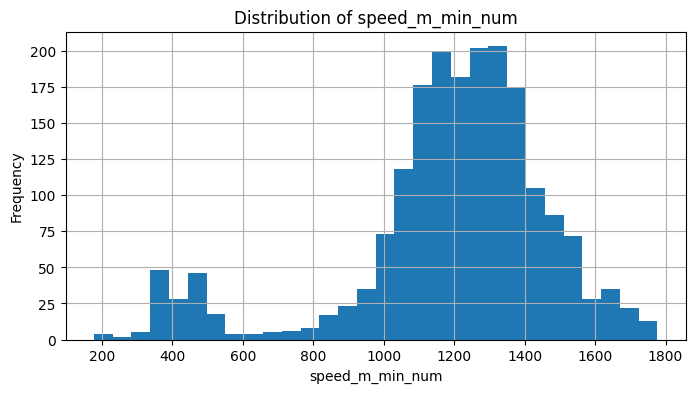

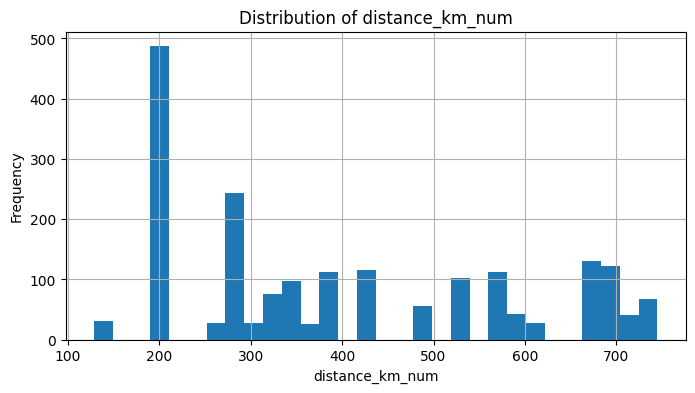

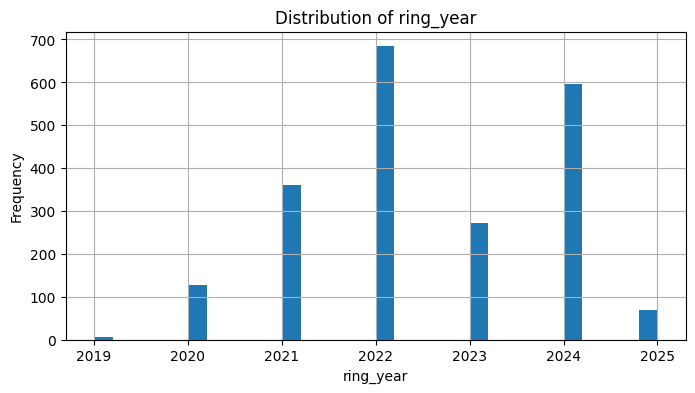

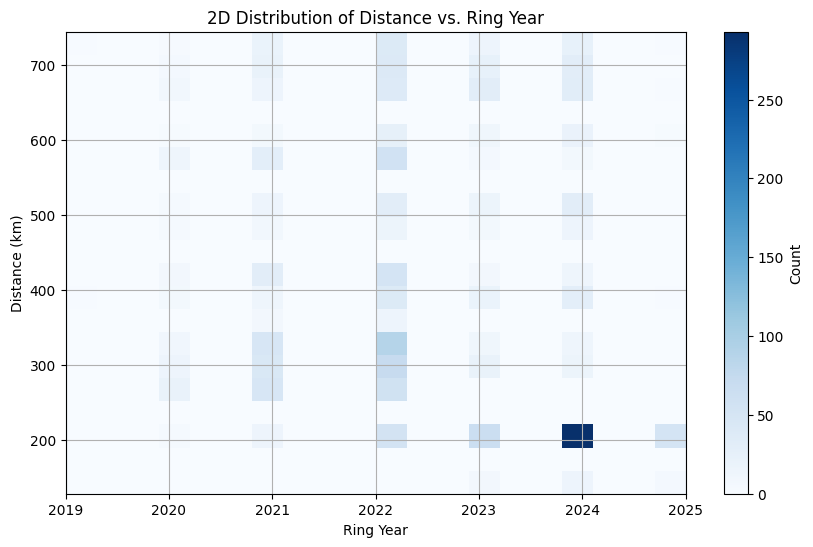

In [ ]:
numeric_cols = [
    "speed_m_min_num", "speed_m_min",
    "distance_km_num", "distance_km",
    "flight_minutes_num", "flight_minutes",
    "loft_race_avg_speed", "loft_race_best_speed", "loft_race_bird_count",
    "speed_vs_loft_avg", "speed_vs_loft_best",
    "rolling_3_avg_speed_before_race", "rolling_5_avg_speed_before_race",
    "rolling_3_best_speed_before_race", "rolling_5_best_speed_before_race",
    "days_since_previous_race", "bird_race_number", "bird_total_races_in_data",
    "hist_temp_c", "hist_wind_kmh", "hist_wind_dir",
    "release_lat", "release_lon",
    "family_depth_score", "ai_training_score", "ai_score",
    "bird_lifetime_avg_speed", "bird_lifetime_best_speed", "bird_lifetime_race_count",
    "parent_pair_avg_speed", "parent_pair_best_speed",
    "parent_a_parent_avg_speed", "parent_a_parent_best_speed",
    "parent_b_parent_avg_speed", "parent_b_parent_best_speed",
    "pairing_avg_speed", "pairing_best_speed",
    "p1_parent_avg_speed", "p1_parent_best_speed",
    "p2_parent_avg_speed", "p2_parent_best_speed",
    "parent_pair_offspring_unique_birds", "parent_pair_offspring_race_rows",
    "pairing_offspring_unique_birds", "pairing_offspring_race_rows",
    "ring_year", "child_ring_year", "ml_target_speed_m_min",
]

for col in numeric_cols:
    if col in df_all.columns:
        df_all[col] = to_num(df_all[col])

# Add fallback columns needed by the model.
if "speed_m_min_num" not in df_all.columns and "speed_m_min" in df_all.columns:
    df_all["speed_m_min_num"] = to_num(df_all["speed_m_min"])

if "distance_km_num" not in df_all.columns and "distance_km" in df_all.columns:
    df_all["distance_km_num"] = to_num(df_all["distance_km"])

if "flight_minutes_num" not in df_all.columns and "flight_minutes" in df_all.columns:
    df_all["flight_minutes_num"] = to_num(df_all["flight_minutes"])

if "ml_target_speed_m_min" not in df_all.columns and "speed_m_min_num" in df_all.columns:
    df_all["ml_target_speed_m_min"] = df_all["speed_m_min_num"]

print("Numeric conversion complete.")

# Visualize distributions of some key numeric columns
print("\nDisplaying distributions for selected numeric columns:")
selected_cols_for_viz = ["speed_m_min_num", "distance_km_num", "ring_year"]
for col_name in selected_cols_for_viz:
    if col_name in df_all.columns:
        plt.figure(figsize=(8, 4))
        df_all[col_name].hist(bins=30)
        plt.title(f'Distribution of {col_name}')
        plt.xlabel(col_name)
        plt.ylabel('Frequency')
        plt.show()
    else:
        print(f"Warning: Column '{col_name}' not found for visualization.")

# Add 2D histogram for distance vs. ring_year to show distribution
if "distance_km_num" in df_all.columns and "ring_year" in df_all.columns:
    # Filter out NaN values before plotting 2D histogram
    plot_data = df_all.dropna(subset=["ring_year", "distance_km_num"])
    if not plot_data.empty:
        plt.figure(figsize=(10, 6))
        # Using hist2d to show the distribution (density) of points
        plt.hist2d(plot_data["ring_year"], plot_data["distance_km_num"], bins=(20, 20), cmap='Blues')
        plt.colorbar(label='Count')
        plt.title('2D Distribution of Distance vs. Ring Year')
        plt.xlabel('Ring Year')
        plt.ylabel('Distance (km)')
        plt.grid(True)
        plt.show()
    else:
        print("Warning: No finite data points for 'distance_km_num' or 'ring_year' after dropping NaNs for 2D histogram.")
else:
    print("Warning: 'distance_km_num' or 'ring_year' column not found for 2D histogram.")

## Step 7 — Prepare dates and training rows

This cell cleans race dates, extracts ring year, and keeps the historical rows that can be used for training.

The model trains on past results. The final prediction still stays locked to available birds only.


In [ ]:
date_col = first_existing(df_all, ["race_date_dt", "race_date", "Date", "P_Date"])
if not date_col:
    raise ValueError("No race date column found.")

df_all["race_date_clean"] = parse_dates(df_all[date_col])
df_all["race_year"] = df_all["race_date_clean"].dt.year

# Extract year from ring number where possible.
if "ring_year" not in df_all.columns:
    df_all["ring_year"] = df_all["ring_norm"].apply(ring_year)
else:
    df_all["ring_year"] = df_all["ring_year"].fillna(df_all["ring_norm"].apply(ring_year))

year_counts = df_all["race_year"].value_counts(dropna=False).sort_index()
print("the configured input tab race-year counts:")
print(year_counts)

# Keep usable historical rows for model training.
df = df_all[df_all["race_year"].isin(TRAINING_SEASONS)].copy()
df = df.dropna(subset=["speed_m_min_num"]).copy()

if df.empty:
    raise ValueError("No usable training rows found.")

df["is_2026_available_candidate"] = df["ring_norm"].isin(available_2026_birds)

available_years = sorted(df["race_year"].dropna().astype(int).unique().tolist())
available_candidates_with_history = sorted(df.loc[df["is_2026_available_candidate"], "ring_norm"].unique().tolist())
available_candidates_no_history = sorted(set(available_2026_birds) - set(available_candidates_with_history))

print("Training rows:", len(df))
print("Training years:", available_years)
print("2026 available candidates with race history:", len(available_candidates_with_history))
print("2026 available candidates with no race history:", len(available_candidates_no_history))


the configured input tab race-year counts:
race_year
2023.00    981
2024.00    104
2025.00    858
NaN        171
Name: count, dtype: int64
Training rows: 1943
Training years: [2023, 2024, 2025]
2026 available candidates with race history: 48
2026 available candidates with no race history: 0


# How the scoring works

The notebook uses two layers.

## Layer 1 — model prediction

The model predicts likely speed for the next race from historical race data, route/weather features, form, family data, and existing AI score fields.

## Layer 2 — final ranking score

The final score combines model prediction with form, family strength, consistency, and the existing AI training score.

This is better than using model speed only, because the fastest predicted bird on paper is not always the best practical basket choice.

## Step 8 — Weather features

This cell turns weather direction into useful race features like tailwind, headwind, and crosswind effect.


In [ ]:
if {"release_lat", "release_lon"}.issubset(df.columns):
    df["flight_bearing"] = df.apply(
        lambda r: haversine_bearing(r["release_lat"], r["release_lon"], LOFT_LAT, LOFT_LON)
        if pd.notna(r["release_lat"]) and pd.notna(r["release_lon"]) else np.nan,
        axis=1,
    )
else:
    df["flight_bearing"] = np.nan

if {"release_lat", "release_lon", "hist_wind_dir", "hist_wind_kmh"}.issubset(df.columns):
    # Calculate wind effect once.
    # Reuse it for tailwind/headwind fields.
    df["tailwind_component"] = df.apply(
        lambda r: wind_component(
            r["release_lat"], r["release_lon"],
            LOFT_LAT, LOFT_LON,
            r["hist_wind_dir"], r["hist_wind_kmh"]
        ),
        axis=1,
    )
    df["tailwind_strength"] = df["tailwind_component"].clip(lower=0)
    df["headwind_strength"] = (-df["tailwind_component"]).clip(lower=0)
else:
    df["tailwind_component"] = np.nan
    df["tailwind_strength"] = np.nan
    df["headwind_strength"] = np.nan

df["wind_label"] = df["tailwind_component"].apply(wind_label)

print("Weather feature build complete.")
print("Rows with tailwind strength data:", df["tailwind_strength"].notna().sum())
print("Rows with headwind strength data:", df["headwind_strength"].notna().sum())


Weather feature build complete.
Rows with tailwind strength data: 1393
Rows with headwind strength data: 1393


## Step 9 — Family and pairing features

This cell builds family and parent-pair signals.

The goal is to give extra context where a bird has strong related birds or a strong parent pairing behind it.

These features should support the ranking, not replace actual race form.


In [ ]:
family_avg_cols = [
    c for c in [
        "parent_pair_avg_speed",
        "parent_a_parent_avg_speed",
        "parent_b_parent_avg_speed",
        "pairing_avg_speed",
        "p1_parent_avg_speed",
        "p2_parent_avg_speed",
    ] if c in df.columns
]

family_best_cols = [
    c for c in [
        "parent_pair_best_speed",
        "parent_a_parent_best_speed",
        "parent_b_parent_best_speed",
        "pairing_best_speed",
        "p1_parent_best_speed",
        "p2_parent_best_speed",
    ] if c in df.columns
]

df["family_avg_speed"] = df.apply(lambda r: safe_mean_row(r, family_avg_cols), axis=1) if family_avg_cols else np.nan
df["family_best_speed"] = df.apply(lambda r: safe_mean_row(r, family_best_cols), axis=1) if family_best_cols else np.nan

if "ai_training_score" not in df.columns and "ai_score" in df.columns:
    df["ai_training_score"] = df["ai_score"]
elif "ai_training_score" not in df.columns:
    df["ai_training_score"] = 0

if "family_depth_score" not in df.columns:
    level_count_cols = [c for c in df.columns if re.match(r"parent_level_\d+_count", c)]
    if level_count_cols:
        df["family_depth_score"] = df[level_count_cols].apply(
            lambda r: pd.to_numeric(r, errors="coerce").fillna(0).sum(),
            axis=1,
        )
    else:
        df["family_depth_score"] = 0

fdmax = df["family_depth_score"].max()
df["family_depth_norm"] = df["family_depth_score"] / fdmax if pd.notna(fdmax) and fdmax > 0 else 0

print("Family feature build complete.")
print("Family avg columns used:", family_avg_cols)
print("Family best columns used:", family_best_cols)
print("Rows with family avg speed:", df["family_avg_speed"].notna().sum())


Family feature build complete.
Family avg columns used: ['parent_pair_avg_speed', 'parent_a_parent_avg_speed', 'parent_b_parent_avg_speed', 'pairing_avg_speed', 'p1_parent_avg_speed', 'p2_parent_avg_speed']
Family best columns used: ['parent_pair_best_speed', 'parent_a_parent_best_speed', 'parent_b_parent_best_speed', 'pairing_best_speed', 'p1_parent_best_speed', 'p2_parent_best_speed']
Rows with family avg speed: 1592


## Step 10 — Recent form features

This cell calculates rolling form from previous races only.

That matters because the model must not use the race result it is trying to predict. No future leakage. No cheating. No fake smart AI.


In [ ]:
df["bird_age_2026"] = AVAILABLE_LIST_YEAR - df["ring_year"]
df["bird_age_2026"] = df["bird_age_2026"].fillna(0).clip(lower=0)

df = df.sort_values(["ring_norm", "race_date_clean"]).reset_index(drop=True)

if "bird_race_number" not in df.columns or df["bird_race_number"].isna().all():
    df["bird_race_number"] = df.groupby("ring_norm").cumcount() + 1

if "bird_total_races_in_data" not in df.columns or df["bird_total_races_in_data"].isna().all():
    df["bird_total_races_in_data"] = df.groupby("ring_norm")["ring_norm"].transform("size")

if "rolling_3_avg_speed_before_race" not in df.columns or df["rolling_3_avg_speed_before_race"].isna().all():
    df["rolling_3_avg_speed_before_race"] = df.groupby("ring_norm")["speed_m_min_num"].transform(
        lambda s: s.shift(1).rolling(3, min_periods=1).mean()
    )

if "rolling_5_avg_speed_before_race" not in df.columns or df["rolling_5_avg_speed_before_race"].isna().all():
    df["rolling_5_avg_speed_before_race"] = df.groupby("ring_norm")["speed_m_min_num"].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).mean()
    )

if "rolling_3_best_speed_before_race" not in df.columns or df["rolling_3_best_speed_before_race"].isna().all():
    df["rolling_3_best_speed_before_race"] = df.groupby("ring_norm")["speed_m_min_num"].transform(
        lambda s: s.shift(1).rolling(3, min_periods=1).max()
    )

if "rolling_5_best_speed_before_race" not in df.columns or df["rolling_5_best_speed_before_race"].isna().all():
    df["rolling_5_best_speed_before_race"] = df.groupby("ring_norm")["speed_m_min_num"].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).max()
    )

if "days_since_previous_race" not in df.columns or df["days_since_previous_race"].isna().all():
    df["prev_race_date_auto"] = df.groupby("ring_norm")["race_date_clean"].shift(1)
    df["days_since_previous_race"] = (df["race_date_clean"] - df["prev_race_date_auto"]).dt.days

df["rest_days_capped"] = df["days_since_previous_race"].clip(0, 60).fillna(14)

print("Form and rolling features ready.")


Form and rolling features ready.


## Step 11 — Career summary per bird

This cell builds career-level fields such as average speed, best speed, race count, and consistency.

These values give the final output more context for manual review.


In [ ]:
career = df.groupby("ring_norm", as_index=False).agg(
    career_races=("speed_m_min_num", "count"),
    career_avg_speed=("speed_m_min_num", "mean"),
    career_best_speed=("speed_m_min_num", "max"),
    career_std=("speed_m_min_num", "std"),
    career_avg_vs_loft=("speed_vs_loft_avg", "mean") if "speed_vs_loft_avg" in df.columns else ("speed_m_min_num", "mean"),
    career_ai_score=("ai_training_score", "mean"),
    career_family_avg=("family_avg_speed", "mean"),
    career_family_best=("family_best_speed", "max"),
    career_family_depth=("family_depth_score", "max"),
    career_avg_tailwind=("tailwind_component", "mean"),
)

display(career.head())


,ring_norm,career_races,career_avg_speed,career_best_speed,career_std,career_avg_vs_loft,career_ai_score,career_family_avg,career_family_best,career_family_depth,career_avg_tailwind
0,LOFTIQ-BIRD-0012,6,1037.41,1547.12,379.81,-58.25,28.47,1037.41,1547.12,0.00,11.92
1,LOFTIQ-BIRD-0015,10,1274.25,1750.55,196.66,14.61,52.77,1274.25,1750.55,0.00,10.57
2,LOFTIQ-BIRD-0016,7,1262.75,1324.66,72.23,49.64,53.31,1262.75,1324.66,1.00,4.24
3,LOFTIQ-BIRD-0018,8,1319.97,1426.19,106.60,40.02,48.46,NaN,NaN,0.00,-0.57
4,LOFTIQ-BIRD-0019,14,1130.20,1482.51,323.00,26.88,39.90,NaN,NaN,0.00,0.82


## Step 12 — Train the model

This cell builds the feature table, splits historical rows in time order, tests the model on later rows, and then refits the final model on all usable training rows.

The time-aware test is important because random splitting can make the model look better than it really is.


Final model: VotingRegressor_RF_HistGradientBoosting
Time-series CV MAE: 44.22 m/min
Holdout MAE: 32.03 m/min
Holdout R2: 0.965
Rows used for final training: 1943
Features used: ['distance_km_num', 'bird_race_number', 'bird_age_2026', 'rolling_3_avg_speed_before_race', 'rolling_5_avg_speed_before_race', 'rolling_3_best_speed_before_race', 'rolling_5_best_speed_before_race', 'rest_days_capped', 'loft_race_avg_speed', 'hist_temp_c', 'hist_wind_kmh', 'hist_wind_dir', 'tailwind_component', 'family_depth_norm', 'family_avg_speed', 'family_best_speed', 'ai_training_score', 'parent_pair_offspring_unique_birds', 'parent_pair_offspring_race_rows', 'pairing_offspring_unique_birds', 'pairing_offspring_race_rows', 'wind_distance_interaction', 'form_momentum', 'speed_vs_loft_ratio']
Final feature importance — permutation based:


,feature,importance
8,loft_race_avg_speed,1.26
16,ai_training_score,0.30
4,rolling_5_avg_speed_before_race,0.02
14,family_avg_speed,0.01
23,speed_vs_loft_ratio,0.01
13,family_depth_norm,0.00
15,family_best_speed,0.00
3,rolling_3_avg_speed_before_race,0.00
6,rolling_5_best_speed_before_race,0.00
22,form_momentum,0.00


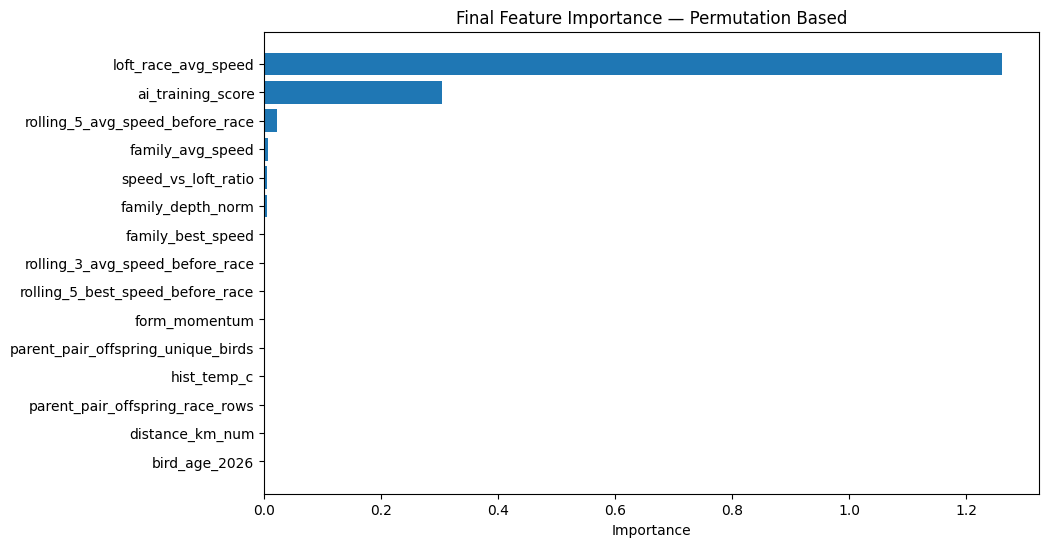

In [ ]:
candidate_features = [
    "distance_km_num",
    "bird_race_number",
    "bird_age_2026",
    "rolling_3_avg_speed_before_race",
    "rolling_5_avg_speed_before_race",
    "rolling_3_best_speed_before_race",
    "rolling_5_best_speed_before_race",
    "rest_days_capped",
    "loft_race_avg_speed",
    "hist_temp_c",
    "hist_wind_kmh",
    "hist_wind_dir",
    "tailwind_component",
    "family_depth_norm",
    "family_avg_speed",
    "family_best_speed",
    "ai_training_score",
    "parent_pair_offspring_unique_birds",
    "parent_pair_offspring_race_rows",
    "pairing_offspring_unique_birds",
    "pairing_offspring_race_rows",
]

target = "ml_target_speed_m_min"


def build_advanced_features(frame):
    """Build advanced features that are safe for both training and prediction rows."""
    out = frame.copy()

    if {"distance_km_num", "tailwind_component"}.issubset(out.columns):
        out["wind_distance_interaction"] = (
            pd.to_numeric(out["distance_km_num"], errors="coerce")
            * pd.to_numeric(out["tailwind_component"], errors="coerce")
        )

    if {"rolling_3_avg_speed_before_race", "rolling_5_avg_speed_before_race"}.issubset(out.columns):
        out["form_momentum"] = (
            pd.to_numeric(out["rolling_3_avg_speed_before_race"], errors="coerce")
            - pd.to_numeric(out["rolling_5_avg_speed_before_race"], errors="coerce")
        )

    if {"rolling_3_avg_speed_before_race", "loft_race_avg_speed"}.issubset(out.columns):
        denom = pd.to_numeric(out["loft_race_avg_speed"], errors="coerce").replace(0, np.nan)
        out["speed_vs_loft_ratio"] = (
            pd.to_numeric(out["rolling_3_avg_speed_before_race"], errors="coerce") / denom
        )

    return out


df = build_advanced_features(df)

advanced_feature_candidates = [
    "wind_distance_interaction",
    "form_momentum",
    "speed_vs_loft_ratio",
]

features = [
    f for f in candidate_features + advanced_feature_candidates
    if f in df.columns
]
features = list(dict.fromkeys(features))

model_df = df.sort_values("race_date_clean").copy()
model_df = model_df.dropna(subset=[target]).copy()

for col in features + [target]:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df = model_df.dropna(subset=[target]).copy()

if len(model_df) < 30:
    raise ValueError(f"Not enough training rows: {len(model_df)}")

X_all = model_df[features].fillna(0)
y_all = model_df[target]

# Test on newer races to avoid fake accuracy.
split_idx = max(1, int(len(model_df) * 0.80))
X_train, X_test = X_all.iloc[:split_idx], X_all.iloc[split_idx:]
y_train, y_test = y_all.iloc[:split_idx], y_all.iloc[split_idx:]

use_advanced_model = len(model_df) >= 60 and len(features) >= 3

if use_advanced_model:
    model_rf = RandomForestRegressor(
        n_estimators=250,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )

    model_gb = HistGradientBoostingRegressor(
        max_iter=200,
        max_depth=7,
        learning_rate=0.08,
        random_state=42,
    )

    model = VotingRegressor(estimators=[
        ("rf", model_rf),
        ("gb", model_gb),
    ])

    n_splits = min(5, max(2, len(model_df) // 20))
    tscv = TimeSeriesSplit(n_splits=n_splits)

    cv_scores = cross_val_score(
        model,
        X_all,
        y_all,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )

    model.fit(X_train, y_train)
    test_preds = model.predict(X_test) if len(X_test) else model.predict(X_train)

    mae = mean_absolute_error(y_test, test_preds) if len(X_test) else float(-cv_scores.mean())
    r2 = r2_score(y_test, test_preds) if len(X_test) >= 2 else np.nan
    model_name = "VotingRegressor_RF_HistGradientBoosting"

    print(f"Final model: {model_name}")
    print(f"Time-series CV MAE: {-cv_scores.mean():.2f} m/min")
    print(f"Holdout MAE: {mae:.2f} m/min")
    print(f"Holdout R2: {r2:.3f}" if pd.notna(r2) else "Holdout R2: not available")

else:
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X_train, y_train)
    test_preds = model.predict(X_test) if len(X_test) else model.predict(X_train)

    mae = mean_absolute_error(y_test, test_preds) if len(X_test) else np.nan
    r2 = r2_score(y_test, test_preds) if len(X_test) >= 2 else np.nan
    model_name = "RandomForestRegressor"

    print(f"Final model: {model_name}")
    print(f"Holdout MAE: {mae:.2f} m/min" if pd.notna(mae) else "Holdout MAE: not available")
    print(f"Holdout R2: {r2:.3f}" if pd.notna(r2) else "Holdout R2: not available")

# Train final model on all usable history.
model.fit(X_all, y_all)

print("Rows used for final training:", len(model_df))
print("Features used:", features)

try:
    result_pi = permutation_importance(
        model,
        X_all,
        y_all,
        n_repeats=5,
        random_state=42,
        n_jobs=-1,
    )

    feature_importance_final = pd.DataFrame({
        "feature": features,
        "importance": result_pi.importances_mean,
    }).sort_values("importance", ascending=False)

    print("Final feature importance — permutation based:")
    display(feature_importance_final.head(15))

    plt.figure(figsize=(10, 6))
    plt.barh(
        feature_importance_final.head(15).sort_values("importance")["feature"],
        feature_importance_final.head(15).sort_values("importance")["importance"],
    )
    plt.title("Final Feature Importance — Permutation Based")
    plt.xlabel("Importance")
    plt.show()

except Exception as e:
    print("Permutation importance skipped:", e)


## Step 13 — Set the next race route and weather

This cell prepares the release point, route distance, race date, temperature, wind speed, wind direction, and wind component for the prediction run.


In [ ]:
NEXT_BEARING = haversine_bearing(NEXT_RELEASE_LAT, NEXT_RELEASE_LON, LOFT_LAT, LOFT_LON)

NEXT_TAILWIND = wind_component(
    NEXT_RELEASE_LAT,
    NEXT_RELEASE_LON,
    LOFT_LAT,
    LOFT_LON,
    NEXT_WIND_DIR,
    NEXT_WIND_KMH,
)

NEXT_WINDLABEL = wind_label(NEXT_TAILWIND)

print("=" * 70)
print("NEXT RACE")
print("Race:", NEXT_RACE_NAME)
print("Date:", NEXT_RACE_DATE)
print("Release:", NEXT_RELEASE_LOC, NEXT_RELEASE_LAT, NEXT_RELEASE_LON)
print("Distance:", NEXT_RACE_DISTANCE, "km")
print("Wind:", NEXT_WINDLABEL, f"{NEXT_TAILWIND:+.1f} km/h")
print("Candidate list: 2026 available birds ONLY")
print("=" * 70)


NEXT RACE
Race: Next Race
Date: 2026-09-06
Release: Graaff-Reinet -32.25 24.53
Distance: 380.0 km
Wind: Tailwind +12.8 km/h
Candidate list: 2026 available birds ONLY


## Step 14 — Create next-race rows

This cell creates one prediction row per available bird that has usable race history.

Available birds with no history are listed in the audit. They are not silently mixed into the ranked table.


In [ ]:
latest = (
    df[df["ring_norm"].isin(available_2026_birds)]
    .sort_values("race_date_clean")
    .groupby("ring_norm", as_index=False)
    .last()
)

available_with_history = sorted(latest["ring_norm"].unique().tolist())
available_without_history = sorted(set(available_2026_birds) - set(available_with_history))

if latest.empty:
    raise ValueError("None of the 2026 available birds have race history in the configured input tab.")

# Fallback route average if exact route history is missing.
route_avg = np.nan
if "race_name" in df.columns and "loft_race_avg_speed" in df.columns:
    route_rows = df[df["race_name"].astype(str).str.contains(NEXT_RELEASE_LOC, case=False, na=False)]
    if not route_rows.empty:
        route_avg = route_rows["loft_race_avg_speed"].mean()

if pd.isna(route_avg) and "loft_race_avg_speed" in df.columns:
    route_avg = df["loft_race_avg_speed"].mean()

if pd.isna(route_avg):
    route_avg = df["speed_m_min_num"].mean()

pred_rows = []

for _, row in latest.iterrows():
    ring_year_val = row.get("ring_year", AVAILABLE_LIST_YEAR)
    if pd.isna(ring_year_val):
        ring_year_val = AVAILABLE_LIST_YEAR

    feat = {
        "ring_norm": row["ring_norm"],
        "distance_km_num": NEXT_RACE_DISTANCE,
        "bird_race_number": (row.get("bird_race_number", 0) if pd.notna(row.get("bird_race_number", np.nan)) else 0) + 1,
        "bird_age_2026": max(AVAILABLE_LIST_YEAR - ring_year_val, 0),
        "rolling_3_avg_speed_before_race": row.get("rolling_3_avg_speed_before_race", row.get("speed_m_min_num", 0)),
        "rolling_5_avg_speed_before_race": row.get("rolling_5_avg_speed_before_race", row.get("speed_m_min_num", 0)),
        "rolling_3_best_speed_before_race": row.get("rolling_3_best_speed_before_race", row.get("speed_m_min_num", 0)),
        "rolling_5_best_speed_before_race": row.get("rolling_5_best_speed_before_race", row.get("speed_m_min_num", 0)),
        "rest_days_capped": min(row.get("days_since_previous_race", 14) if pd.notna(row.get("days_since_previous_race", np.nan)) else 14, 60),
        "loft_race_avg_speed": route_avg,
        "hist_temp_c": NEXT_TEMP_C,
        "hist_wind_kmh": NEXT_WIND_KMH,
        "hist_wind_dir": NEXT_WIND_DIR,
        "tailwind_component": NEXT_TAILWIND,
        "family_depth_norm": row.get("family_depth_norm", 0),
        "family_avg_speed": row.get("family_avg_speed", 0),
        "family_best_speed": row.get("family_best_speed", 0),
        "ai_training_score": row.get("ai_training_score", 0),
        "parent_pair_offspring_unique_birds": row.get("parent_pair_offspring_unique_birds", row.get("pairing_offspring_unique_birds", 0)),
        "parent_pair_offspring_race_rows": row.get("parent_pair_offspring_race_rows", row.get("pairing_offspring_race_rows", 0)),
        "pairing_offspring_unique_birds": row.get("pairing_offspring_unique_birds", 0),
        "pairing_offspring_race_rows": row.get("pairing_offspring_race_rows", 0),
    }

    pred_rows.append(feat)

pred_df = pd.DataFrame(pred_rows)
pred_df = build_advanced_features(pred_df)

for col in features:
    if col not in pred_df.columns:
        pred_df[col] = 0
    pred_df[col] = to_num(pred_df[col])

pred_df = pred_df.fillna(0)
pred_df["predicted_speed"] = model.predict(pred_df[features]).round(1)

print("Prediction rows built:", len(pred_df))
print("Available birds without race history:", len(available_without_history))


Prediction rows built: 48
Available birds without race history: 0


/tmp/ipykernel_12638/3878974017.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .last()


## Step 15 — Build the final score

The final score blends several signals:

| Signal | Weight | Meaning |
|---|---:|---|
| Model speed | 45% | Predicted next-race speed |
| Existing AI score | 20% | Current internal training score |
| Recent form | 15% | Rolling speed/form |
| Family strength | 10% | Bloodline and pairing support |
| Consistency | 10% | Less speed variation gets rewarded |

The output is sorted by the final composite score.


In [ ]:
pred_df["score_ml"] = minmax_norm(pred_df["predicted_speed"])
pred_df["score_ai"] = minmax_norm(pred_df["ai_training_score"]) if "ai_training_score" in pred_df.columns else 0.5
pred_df["score_form"] = minmax_norm(pred_df["rolling_3_avg_speed_before_race"]) if "rolling_3_avg_speed_before_race" in pred_df.columns else 0.5
pred_df["score_family"] = minmax_norm(pred_df["family_avg_speed"]) if "family_avg_speed" in pred_df.columns else 0.5

career_std = df.groupby("ring_norm")["speed_m_min_num"].std()
career_std = career_std.fillna(career_std.mean())
pred_df = pred_df.join(career_std.rename("career_std"), on="ring_norm")
pred_df["score_consistency"] = minmax_norm(-pred_df["career_std"].fillna(pred_df["career_std"].max()))

pred_df["composite_score"] = (
    0.45 * pred_df["score_ml"]
    + 0.20 * pred_df["score_ai"]
    + 0.15 * pred_df["score_form"]
    + 0.10 * pred_df["score_family"]
    + 0.10 * pred_df["score_consistency"]
).round(4)

pred_df = pred_df.sort_values("composite_score", ascending=False).reset_index(drop=True)
pred_df["rank"] = pred_df.index + 1

display(pred_df.head(10))


,ring_norm,distance_km_num,bird_race_number,bird_age_2026,rolling_3_avg_speed_before_race,rolling_5_avg_speed_before_race,rolling_3_best_speed_before_race,rolling_5_best_speed_before_race,rest_days_capped,loft_race_avg_speed,hist_temp_c,hist_wind_kmh,hist_wind_dir,tailwind_component,family_depth_norm,family_avg_speed,family_best_speed,ai_training_score,parent_pair_offspring_unique_birds,parent_pair_offspring_race_rows,pairing_offspring_unique_birds,pairing_offspring_race_rows,wind_distance_interaction,form_momentum,speed_vs_loft_ratio,predicted_speed,score_ml,score_ai,score_form,score_family,career_std,score_consistency,composite_score,rank
0,LOFTIQ-BIRD-0279,380.00,13,2.00,1227.50,1236.85,1385.53,1385.53,15.00,1133.54,18.00,20.00,155.00,12.80,0.20,1273.22,1598.83,65.52,4.00,49.00,4.00,49.00,4864.00,-9.35,1.08,1196.10,0.96,0.96,0.65,0.82,124.21,0.92,0.89,1
1,LOFTIQ-BIRD-0235,380.00,15,3.00,1163.93,1274.74,1201.11,1530.14,8.00,1133.54,18.00,20.00,155.00,12.80,0.20,1284.78,1521.24,66.71,1.00,14.00,1.00,14.00,4864.00,-110.81,1.03,1203.40,0.97,0.99,0.58,0.86,162.68,0.82,0.89,2
2,LOFTIQ-BIRD-0280,380.00,15,2.00,1170.34,1241.29,1257.83,1500.79,14.00,1133.54,18.00,20.00,155.00,12.80,0.20,1273.22,1598.83,66.95,4.00,49.00,4.00,49.00,4864.00,-70.95,1.03,1202.60,0.97,1.00,0.58,0.82,164.77,0.82,0.89,3
3,LOFTIQ-BIRD-0221,380.00,16,3.00,1393.66,1194.45,1566.19,1566.19,14.00,1133.54,18.00,20.00,155.00,12.80,0.20,1272.50,1491.79,65.25,3.00,19.00,3.00,19.00,4864.00,199.21,1.23,1194.80,0.95,0.96,0.85,0.82,268.22,0.56,0.88,4
4,LOFTIQ-BIRD-0270,380.00,9,2.00,1281.77,1237.54,1374.97,1374.97,9.00,1133.54,18.00,20.00,155.00,12.80,0.40,1205.30,1395.42,66.63,4.00,49.00,4.00,49.00,4864.00,44.23,1.13,1186.40,0.93,0.99,0.71,0.57,125.01,0.92,0.87,5
5,LOFTIQ-BIRD-0293,380.00,15,2.00,1296.34,1282.70,1368.36,1368.36,6.00,1133.54,18.00,20.00,155.00,12.80,0.40,1242.26,1492.28,58.69,3.00,33.00,3.00,33.00,4864.00,13.64,1.14,1192.10,0.95,0.80,0.73,0.71,108.90,0.96,0.86,6
6,LOFTIQ-BIRD-0176,380.00,11,4.00,1526.40,1398.97,1714.78,1714.78,60.00,1133.54,18.00,20.00,155.00,12.80,0.00,1244.03,1714.78,59.67,2.00,26.00,1.00,10.00,4864.00,127.43,1.35,1176.30,0.91,0.82,1.00,0.71,243.51,0.62,0.86,7
7,LOFTIQ-BIRD-0249,380.00,11,2.00,1324.66,1294.90,1456.13,1456.13,14.00,1133.54,18.00,20.00,155.00,12.80,0.20,1246.52,1630.83,54.89,2.00,23.00,2.00,23.00,4864.00,29.76,1.17,1174.70,0.91,0.70,0.76,0.72,127.76,0.91,0.83,8
8,LOFTIQ-BIRD-0274,380.00,9,2.00,1332.54,1206.63,1441.07,1441.07,14.00,1133.54,18.00,20.00,155.00,12.80,0.00,1192.12,1548.22,56.05,2.00,22.00,2.00,22.00,4864.00,125.91,1.18,1199.20,0.96,0.73,0.77,0.52,192.73,0.75,0.82,9
9,LOFTIQ-BIRD-0253,380.00,9,2.00,1260.27,1255.41,1423.22,1437.18,7.00,1133.54,18.00,20.00,155.00,12.80,0.00,1280.74,1628.88,54.09,4.00,43.00,4.00,43.00,4864.00,4.86,1.11,1178.90,0.92,0.68,0.69,0.85,173.76,0.79,0.82,10


## Step 16 — Add bird details

This cell adds useful profile fields to the prediction table: sex, colour, status, race cage year, parent rings, pair key, career stats, and best historical race where available.

The ranking gives the shortlist. These fields help you inspect why a bird landed there.


In [ ]:
result = pred_df.merge(career, on="ring_norm", how="left")

# Bird details from the latest row.
meta_candidates = [
    "ring_norm",
    "ring_year",
    "Sex",
    "Status",
    "Race Cage Year(s)",
    "Word Color(s)",
    "word_color",
    "word_color_family",
    "word_colors",
    "parent_pair_key",
    "pairing_key",
    "parent_a_selected_ring",
    "parent_b_selected_ring",
    "parent_a_ring",
    "parent_b_ring",
    "parent_a_number",
    "parent_b_number",
    "parent_role_warning",
]

meta_cols = [c for c in meta_candidates if c in latest.columns]
meta = latest[meta_cols].copy()

result = result.merge(meta, on="ring_norm", how="left")

# Make sure expected output columns exist.
if "Color" not in result.columns:
    color_source = first_existing(result, ["Word Color(s)", "word_color", "word_color_family", "word_colors"])
    result["Color"] = result[color_source] if color_source else ""

if "Sex" not in result.columns:
    result["Sex"] = ""

if "Status" not in result.columns:
    result["Status"] = ""

if "parent_pair_key" not in result.columns and "pairing_key" in result.columns:
    result["parent_pair_key"] = result["pairing_key"]

if "parent_a_selected_ring" not in result.columns and "parent_a_ring" in result.columns:
    result["parent_a_selected_ring"] = result["parent_a_ring"]

if "parent_b_selected_ring" not in result.columns and "parent_b_ring" in result.columns:
    result["parent_b_selected_ring"] = result["parent_b_ring"]

# Add each bird's best past race.
eligible_hist = df[df["ring_norm"].isin(available_2026_birds)].dropna(subset=["speed_m_min_num"]).copy()
idx = eligible_hist.groupby("ring_norm")["speed_m_min_num"].idxmax()

best_race_cols = ["ring_norm", "race_name", "race_date_clean", "speed_m_min_num", "distance_km_num", "wind_label"]
best_race_cols = [c for c in best_race_cols if c in eligible_hist.columns]

best_race = eligible_hist.loc[idx, best_race_cols].copy()
best_race = best_race.rename(columns={
    "race_name": "best_race",
    "race_date_clean": "best_race_date",
    "speed_m_min_num": "best_speed",
    "distance_km_num": "best_race_distance",
    "wind_label": "best_race_wind",
})

result = result.merge(best_race, on="ring_norm", how="left")

# Add run details to the output.
result.insert(0, "candidate_rule", "ONLY Race Cage Year(s) contains 2026 and Status Active")
result.insert(1, "prediction_race_name", NEXT_RACE_NAME)
result.insert(2, "prediction_race_date", NEXT_RACE_DATE)
result.insert(3, "prediction_release_location", NEXT_RELEASE_LOC)
result.insert(4, "prediction_distance_km", NEXT_RACE_DISTANCE)
result.insert(5, "prediction_weather", f"{NEXT_WINDLABEL} {NEXT_TAILWIND:+.1f} km/h, {NEXT_TEMP_C}C")
result.insert(6, "available_list_year", AVAILABLE_LIST_YEAR)
result.insert(7, "model_mae_m_min", round(mae, 2))
result.insert(8, "model_r2", round(r2, 3))

# Final safety check: keep only available 2026 birds.
result = result[result["ring_norm"].isin(available_2026_birds)].copy()

display_cols = [
    "rank",
    "ring_norm",
    "Sex",
    "ring_year",
    "Color",
    "Status",
    "Race Cage Year(s)",
    "predicted_speed",
    "composite_score",
    "career_avg_speed",
    "career_best_speed",
    "career_races",
    "career_ai_score",
    "rolling_3_avg_speed_before_race",
    "rolling_5_avg_speed_before_race",
    "career_avg_vs_loft",
    "career_family_avg",
    "career_family_best",
    "career_family_depth",
    "best_race",
    "best_speed",
    "best_race_wind",
    "parent_pair_key",
    "parent_a_selected_ring",
    "parent_b_selected_ring",
]

print("Predictions — 2026 available list ONLY:")
display(result[[c for c in display_cols if c in result.columns]].head(TOP_N))


Predictions — 2026 available list ONLY:


,rank,ring_norm,Sex,ring_year,Color,Status,predicted_speed,composite_score,career_avg_speed,career_best_speed,career_races,career_ai_score,rolling_3_avg_speed_before_race,rolling_5_avg_speed_before_race,career_avg_vs_loft,career_family_avg,career_family_best,career_family_depth,best_race,best_speed,best_race_wind,parent_pair_key,parent_a_selected_ring,parent_b_selected_ring
0,1,LOFTIQ-BIRD-0279,,2024.00,"BB/C, BB/C, BB/C",,1196.10,0.89,1279.29,1475.05,12,60.56,1227.50,1236.85,-1.20,1273.22,1598.83,1.00,Colesberg Sprint 1,1475.05,Tailwind,198__877,LOFTIQ-BIRD-0234,None
1,2,LOFTIQ-BIRD-0235,,2023.00,"BB/C, BB/H, BB/H *, BB/C, BB/H, BB/H *",,1203.40,0.89,1267.15,1552.01,14,62.11,1163.93,1274.74,30.71,1284.78,1521.24,1.00,Laingsburg Ope 4,1552.01,Tailwind,207__1496,LOFTIQ-BIRD-0292,None
2,3,LOFTIQ-BIRD-0280,,2024.00,"BB/C, BB/C, BB/C",,1202.60,0.89,1263.64,1500.79,14,58.23,1170.34,1241.29,-14.40,1273.22,1598.83,1.00,Laingsburg Ope 1,1500.79,Tailwind,198__877,LOFTIQ-BIRD-0234,None
3,4,LOFTIQ-BIRD-0221,,2023.00,"BB/H, BB/H *, BB/C, BB/H, BB/H, BB/H *, BB/C",,1194.80,0.88,1282.11,1629.31,15,64.70,1393.66,1194.45,61.13,1272.50,1491.79,1.00,Colesberg Sprint 8,1629.31,Tailwind,369__369,LOFTIQ-BIRD-0304,LOFTIQ-BIRD-0304
4,5,LOFTIQ-BIRD-0270,,2024.00,"BB/C, BB/C, BB/C, BB/C",,1186.40,0.87,1275.23,1420.20,8,59.03,1281.77,1237.54,12.73,1205.30,1395.42,2.00,Colesberg Sprint 5,1420.20,Tailwind,3006__8782,LOFTIQ-BIRD-0141,None
5,6,LOFTIQ-BIRD-0293,,2024.00,"BB/H, BB/H, BB/H",,1192.10,0.86,1277.57,1492.28,14,55.80,1296.34,1282.70,29.61,1242.26,1492.28,2.00,Colesberg Sprint 1,1492.28,Tailwind,113__682,LOFTIQ-BIRD-0006,LOFTIQ-BIRD-0017
6,7,LOFTIQ-BIRD-0176,,2022.00,"BB/WF/C, BB/C, BB/H *, BB/H, BB/WF/C, BB/C, BB...",,1176.30,0.86,1328.27,1714.78,10,55.46,1526.40,1398.97,36.91,1244.03,1714.78,0.00,Matjiesfontein Ope 4,1714.78,Tailwind,6145__6183,None,None
7,8,LOFTIQ-BIRD-0249,,2024.00,"CH/H, CH/H, CH/H",,1174.70,0.83,1255.35,1456.13,10,54.21,1324.66,1294.90,34.38,1246.52,1630.83,1.00,Colesberg Sprint 13,1456.13,Crosswind,135__114561,None,LOFTIQ-BIRD-0239
8,9,LOFTIQ-BIRD-0274,,2024.00,"BB/C, BB/H, BB/C, BB/H",,1199.20,0.82,1224.44,1441.07,8,47.26,1332.54,1206.63,-33.83,1192.12,1548.22,0.00,Colesberg Sprint 13,1441.07,Crosswind,646__1315,None,None
9,10,LOFTIQ-BIRD-0253,,2024.00,"BB/H, BB/H, BB/H",,1178.90,0.82,1298.80,1493.55,8,56.42,1260.27,1255.41,18.76,1280.74,1628.88,0.00,Colesberg Sprint 1,1493.55,Tailwind,5846__8970,None,None


## Step 17 — Plot the top predictions

This cell shows two quick charts:

1. top birds by final score,
2. top birds by predicted speed.

If those two disagree, check the form, family, and consistency columns.


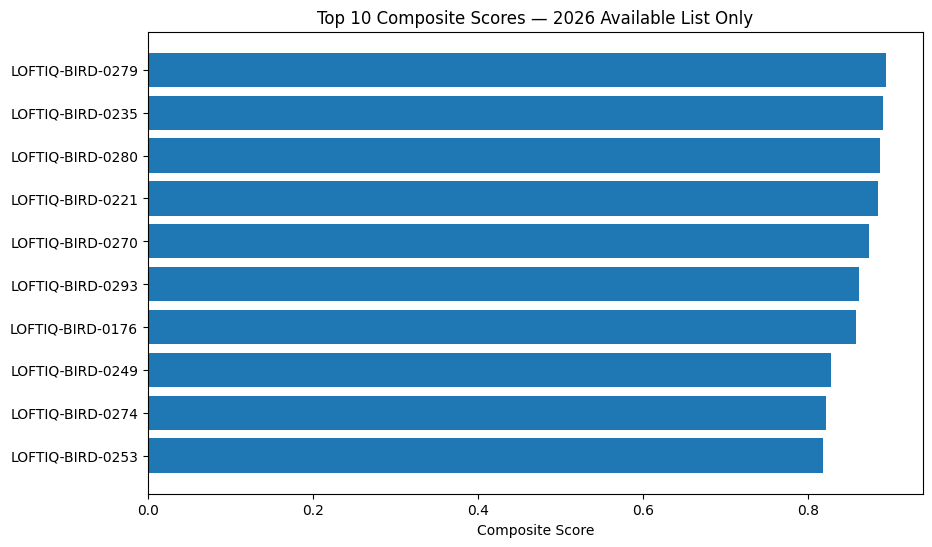

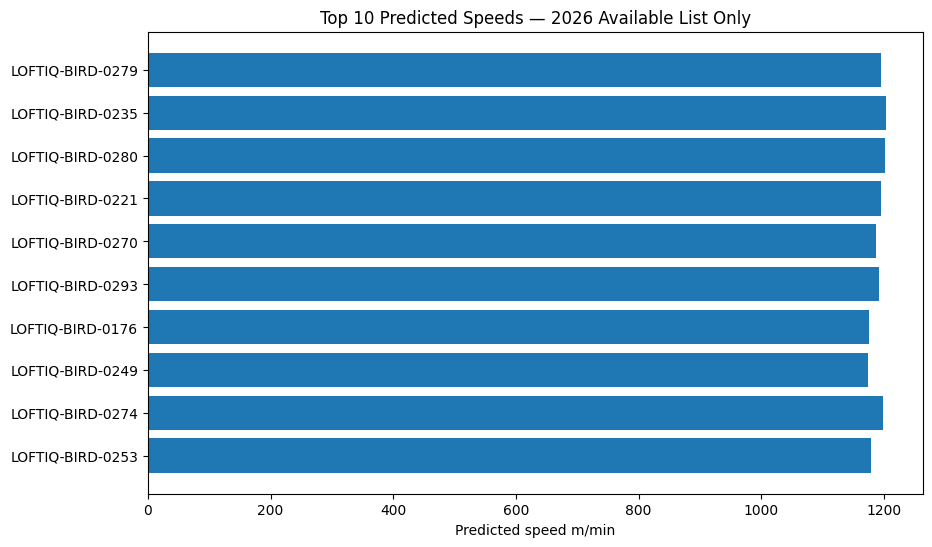

In [ ]:
top10 = result.head(10).copy()

plt.figure(figsize=(10, 6))
plt.barh(top10["ring_norm"][::-1], top10["composite_score"][::-1])
plt.title(f"Top {len(top10)} Composite Scores — 2026 Available List Only")
plt.xlabel("Composite Score")
plt.show()

plt.figure(figsize=(10, 6))
plt.barh(top10["ring_norm"][::-1], top10["predicted_speed"][::-1])
plt.title(f"Top {len(top10)} Predicted Speeds — 2026 Available List Only")
plt.xlabel("Predicted speed m/min")
plt.show()


## Step 18 — Build Best 40 and pair-performance output

This cell creates:

```text
Best_40_Available_Birds
Pair_Performance_Available_Birds
```

Best 40 is the practical shortlist. Pair performance helps check whether the ranking is supported by breeding/family evidence.


In [ ]:
best40 = result.head(40).copy()

pair_key_col = None
if "parent_pair_key" in df.columns:
    pair_key_col = "parent_pair_key"
elif "pairing_key" in df.columns:
    pair_key_col = "pairing_key"

if pair_key_col:
    pair_source = df[df["ring_norm"].isin(available_2026_birds)].copy()
    pair_source = pair_source[pair_source[pair_key_col].astype(str).str.strip() != ""].copy()
    pair_source["parent_pair_key_final"] = pair_source[pair_key_col]
else:
    pair_source = pd.DataFrame()

if not pair_source.empty:
    pair_perf = pair_source.groupby("parent_pair_key_final", as_index=False).agg(
        offspring_birds=("ring_norm", "nunique"),
        race_entries=("ring_norm", "count"),
        offspring_avg_speed=("speed_m_min_num", "mean"),
        offspring_best_speed=("speed_m_min_num", "max"),
        avg_vs_loft=("speed_vs_loft_avg", "mean") if "speed_vs_loft_avg" in pair_source.columns else ("speed_m_min_num", "mean"),
        avg_ai_score=("ai_training_score", "mean"),
        family_depth=("family_depth_score", "max"),
    ).round(2)
    pair_perf = pair_perf.sort_values(["offspring_avg_speed", "offspring_birds"], ascending=False)
else:
    pair_perf = pd.DataFrame()

print("Best 40:")
display(best40)

print("Pair performance — 2026 available birds only:")
display(pair_perf.head(40) if not pair_perf.empty else pair_perf)

# --- Start of widget code for interactive inputs (demonstration) ---
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd # Ensure pandas is imported for pd.to_datetime

print("\n-- Interactive Race Parameters (for demonstration) --")

# Assuming KNOWN_LOCATIONS and NEXT_RACE_DATE are available in the kernel namespace
# from earlier cell execution.

location_options = list(KNOWN_LOCATIONS.keys())
current_location_value = NEXT_RELEASE_LOC if 'NEXT_RELEASE_LOC' in globals() else location_options[0]
current_date_value = pd.to_datetime(NEXT_RACE_DATE) if 'NEXT_RACE_DATE' in globals() else pd.Timestamp.today()


location_widget = widgets.Dropdown(
    options=location_options,
    value=current_location_value,
    description='Select Location:',
    disabled=False,
)

date_widget = widgets.DatePicker(
    value=current_date_value,
    description='Select Date:',
    disabled=False,
)

# Output area for widget feedback
widget_output = widgets.Output()

def on_params_change(change):
    with widget_output:
        clear_output(wait=True)
        print(f"New Location selected: {location_widget.value}")
        print(f"New Date selected: {date_widget.value}")
        print("Note: To update the prediction results based on these selections,")
        print("you would typically need to re-run the relevant configuration and processing cells.")
        # Re-display the static dataframes from this cell for illustration
        print("\nBest 40 (static for this run):")
        display(best40)
        print("\nPair Performance (static for this run):")
        display(pair_perf.head(40) if not pair_perf.empty else pair_perf)


location_widget.observe(on_params_change, names='value')
date_widget.observe(on_params_change, names='value')

# Display widgets and initial output
display(location_widget, date_widget, widget_output)

# Initial display when the cell runs
with widget_output:
    print(f"Current configured Location: {location_widget.value}")
    print(f"Current configured Date: {date_widget.value}")
    print("Note: These widgets demonstrate input but do not dynamically re-calculate the above outputs in this cell.")
    print("\nBest 40 (static for this run):")
    display(best40)
    print("\nPair Performance (static for this run):")
    display(pair_perf.head(40) if not pair_perf.empty else pair_perf)

# --- End of widget code ---

Best 40:


,candidate_rule,prediction_race_name,prediction_race_date,prediction_release_location,prediction_distance_km,prediction_weather,available_list_year,model_mae_m_min,model_r2,ring_norm,distance_km_num,bird_race_number,bird_age_2026,rolling_3_avg_speed_before_race,rolling_5_avg_speed_before_race,rolling_3_best_speed_before_race,rolling_5_best_speed_before_race,rest_days_capped,loft_race_avg_speed,hist_temp_c,hist_wind_kmh,hist_wind_dir,tailwind_component,family_depth_norm,family_avg_speed,family_best_speed,ai_training_score,parent_pair_offspring_unique_birds,parent_pair_offspring_race_rows,pairing_offspring_unique_birds,pairing_offspring_race_rows,wind_distance_interaction,form_momentum,speed_vs_loft_ratio,predicted_speed,score_ml,score_ai,score_form,score_family,career_std_x,score_consistency,composite_score,rank,career_races,career_avg_speed,career_best_speed,career_std_y,career_avg_vs_loft,career_ai_score,career_family_avg,career_family_best,career_family_depth,career_avg_tailwind,ring_year,Word Color(s),word_color,word_color_family,word_colors,parent_pair_key,pairing_key,parent_a_selected_ring,parent_b_selected_ring,parent_a_ring,parent_b_ring,parent_a_number,parent_b_number,parent_role_warning,Color,Sex,Status,best_race,best_race_date,best_speed,best_race_distance,best_race_wind
0,ONLY Race Cage Year(s) contains 2026 and Statu...,Next Race,2026-09-06,Graaff-Reinet,380.00,"Tailwind +12.8 km/h, 18.0C",2026,32.03,0.96,LOFTIQ-BIRD-0279,380.00,13,2.00,1227.50,1236.85,1385.53,1385.53,15.00,1133.54,18.00,20.00,155.00,12.80,0.20,1273.22,1598.83,65.52,4.00,49.00,4.00,49.00,4864.00,-9.35,1.08,1196.10,0.96,0.96,0.65,0.82,124.21,0.92,0.89,1,12,1279.29,1475.05,124.21,-1.20,60.56,1273.22,1598.83,1.00,4.38,2024.00,"BB/C, BB/C, BB/C","BB/C | BB/C, BB/C","BB/C, BB/C | BB/C | BB/C | BB/C, BB/C","BB/C, BB/C | BB/C",198__877,198__877,LOFTIQ-BIRD-0234,None,LOFTIQ-BIRD-0234,None,198.00,877.00,YEAR-AWARE SORTED PAIR: parent_a/parent_b are ...,"BB/C, BB/C, BB/C",,,Colesberg Sprint 1,2025-05-30,1475.05,204.34,Tailwind
1,ONLY Race Cage Year(s) contains 2026 and Statu...,Next Race,2026-09-06,Graaff-Reinet,380.00,"Tailwind +12.8 km/h, 18.0C",2026,32.03,0.96,LOFTIQ-BIRD-0235,380.00,15,3.00,1163.93,1274.74,1201.11,1530.14,8.00,1133.54,18.00,20.00,155.00,12.80,0.20,1284.78,1521.24,66.71,1.00,14.00,1.00,14.00,4864.00,-110.81,1.03,1203.40,0.97,0.99,0.58,0.86,162.68,0.82,0.89,2,14,1267.15,1552.01,162.68,30.71,62.11,1284.78,1521.24,1.00,2.29,2023.00,"BB/C, BB/H, BB/H *, BB/C, BB/H, BB/H *","BB/C | BB/H | BB/H * | BB/C, BB/H, BB/H *","BB/C, BB/H, BB/H * | BB/C | BB/H | BB/H * | BB...","BB/C, BB/H, BB/H * | BB/C | BB/H | BB/H *",207__1496,1496__207,LOFTIQ-BIRD-0292,None,LOFTIQ-BIRD-0292,None,207.00,1496.00,YEAR-AWARE SORTED PAIR: parent_a/parent_b are ...,"BB/C, BB/H, BB/H *, BB/C, BB/H, BB/H *",,,Laingsburg Ope 4,2024-09-29,1552.01,676.88,Tailwind
2,ONLY Race Cage Year(s) contains 2026 and Statu...,Next Race,2026-09-06,Graaff-Reinet,380.00,"Tailwind +12.8 km/h, 18.0C",2026,32.03,0.96,LOFTIQ-BIRD-0280,380.00,15,2.00,1170.34,1241.29,1257.83,1500.79,14.00,1133.54,18.00,20.00,155.00,12.80,0.20,1273.22,1598.83,66.95,4.00,49.00,4.00,49.00,4864.00,-70.95,1.03,1202.60,0.97,1.00,0.58,0.82,164.77,0.82,0.89,3,14,1263.64,1500.79,164.77,-14.40,58.23,1273.22,1598.83,1.00,6.34,2024.00,"BB/C, BB/C, BB/C","BB/C | BB/C, BB/C","BB/C, BB/C | BB/C | BB/C | BB/C, BB/C","BB/C, BB/C | BB/C",198__877,198__877,LOFTIQ-BIRD-0234,None,LOFTIQ-BIRD-0234,None,198.00,877.00,YEAR-AWARE SORTED PAIR: parent_a/parent_b are ...,"BB/C, BB/C, BB/C",,,Laingsburg Ope 1,2025-08-23,1500.79,676.88,Tailwind
3,ONLY Race Cage Year(s) contains 2026 and Statu...,Next Race,2026-09-06,Graaff-Reinet,380.00,"Tailwind +12.8 km/h, 18.0C",2026,32.03,0.96,LOFTIQ-BIRD-0221,380.00,16,3.00,1393.66,1194.45,1566.19,1566.19,14.00,1133.54,18.00,20.00,155.00,12.80,0.20,1272.50,1491.79,65.25,3.00,19.00,3.00,19.00,4864.00,199.21,1.23,1194.80,0.95,0.96,0.85,0.82,268.22,0.56,0.88,4,15,1282.11,1629.31,268.22,61.13,64.70,1272.50,1

Pair performance — 2026 available birds only:


,parent_pair_key_final,offspring_birds,race_entries,offspring_avg_speed,offspring_best_speed,avg_vs_loft,avg_ai_score,family_depth
26,6145__6183,1,10,1328.27,1714.78,36.91,55.46,0.00
12,283__942,1,24,1321.09,1668.90,10.89,57.92,0.00
8,1635__2844,1,17,1309.68,1627.80,38.52,57.57,1.00
31,945__945,1,14,1295.28,1580.64,30.33,63.02,1.00
20,369__369,1,15,1282.11,1629.31,61.13,64.70,1.00
13,2943__5873,2,16,1280.69,1629.53,7.13,60.71,1.00
11,207__1496,1,14,1267.15,1552.01,30.71,62.11,1.00
25,5846__8970,3,30,1266.07,1628.88,-2.08,52.44,0.00
30,891__4720,1,17,1259.99,1577.33,-16.60,49.45,0.00
6,1477__6713,1,6,1256.70,1440.05,-55.44,46.61,0.00



-- Interactive Race Parameters (for demonstration) --


Dropdown(description='Select Location:', options=('Graaff-Reinet', 'Middelburg', 'Cradock', 'Prince Albert', '…

DatePicker(value=Timestamp('2026-09-06 00:00:00'), description='Select Date:')

Output()

## Step 19 — Create the audit report

The audit report records how the run worked: available birds found, birds with history, birds without history, training rows, features used, and holdout scores.

Check this before trusting the prediction output. If the audit looks wrong, the ranking is probably wrong too.


In [ ]:
audit = pd.DataFrame([
    {"metric": "run_time", "value": datetime.now().strftime("%Y-%m-%d %H:%M:%S")},
    {"metric": "candidate_rule", "value": "Race Cage Year(s) contains 2026 AND Status Active"},
    {"metric": "master_input_rows_loaded", "value": len(raw_df)},
    {"metric": "master_input_columns_loaded", "value": len(raw_df.columns)},
    {"metric": "availability_column_used", "value": available_col},
    {"metric": "status_column_used", "value": status_col if status_col else "none"},
    {"metric": "available_2026_active_birds", "value": len(available_2026_birds)},
    {"metric": "available_2026_birds_with_race_history", "value": len(available_with_history)},
    {"metric": "available_2026_birds_without_race_history", "value": len(available_without_history)},
    {"metric": "usable_training_rows", "value": len(df)},
    {"metric": "training_years_available", "value": ", ".join(map(str, available_years))},
    {"metric": "model_name", "value": model_name},
    {"metric": "model_mae_m_min", "value": round(mae, 2)},
    {"metric": "model_r2", "value": round(r2, 3)},
    {"metric": "features_used", "value": " | ".join(features)},
    {"metric": "next_race", "value": NEXT_RACE_NAME},
    {"metric": "next_race_distance", "value": NEXT_RACE_DISTANCE},
    {"metric": "next_race_wind", "value": f"{NEXT_WINDLABEL} {NEXT_TAILWIND:+.1f} km/h"},
])

display(audit)

if available_without_history:
    print("2026 available birds without race history:")
    print(available_without_history)


,metric,value
0,run_time,2026-05-11 14:33:41
1,candidate_rule,Race Cage Year(s) contains 2026 AND Status Active
2,master_input_rows_loaded,2114
3,master_input_columns_loaded,243
4,availability_column_used,race_cage_year_s
5,status_column_used,status
6,available_2026_active_birds,48
7,available_2026_birds_with_race_history,48
8,available_2026_birds_without_race_history,0
9,usable_training_rows,1943


## Step 20 — Write outputs to Google Sheets

This cell writes the final tables back to the configured Google Sheet.

Output tabs:

```text
Predictions_Available_Birds
Best_40_Available_Birds
Prediction_Audit
Pair_Performance_Available_Birds
```


In [ ]:
if WRITE_OUTPUTS:
    write_df_to_csv(OUTPUT_PREDICTIONS, result)
    write_df_to_csv(OUTPUT_BEST40, best40)
    write_df_to_csv(OUTPUT_AUDIT, audit)
    if not pair_perf.empty:
        write_df_to_csv(OUTPUT_PAIR_PERFORMANCE, pair_perf)

print("DONE. Predictions used ONLY the 2026 available/main list.")


Wrote 48 rows to: outputs/predictions_available_birds.csv
Wrote 40 rows to: outputs/best_40_available_birds.csv
Wrote 18 rows to: outputs/prediction_audit.csv
Wrote 32 rows to: outputs/pair_performance_available_birds.csv
DONE. Predictions used ONLY the 2026 available/main list.


# How to read the output

Use the tabs together.

## `Predictions_Available_Birds`

Full ranked list with model score, final score, form, family, and profile fields.

## `Best_40_Available_Birds`

The practical shortlist.

## `Prediction_Audit`

Shows what the notebook used and whether the run looks clean.

## `Pair_Performance_Available_Birds`

Shows parent-pair performance linked to the available birds.

## After each race

1. Add the actual result back into `L2`.
2. Add actual weather and route data where possible.
3. Re-run the notebook.
4. Compare predicted ranking against actual results.
5. Keep improving the input data.

The model improves when the data improves. Dirty data still beats AI with a stick.
